<a href="https://colab.research.google.com/github/FrenklinV/drone-segmentation-baseline/blob/main/peatland_segmentation_baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
print("GPU available:", torch.cuda.is_available())
print("Device name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "none")


GPU available: True
Device name: Tesla T4


In [ ]:
!pip install kaggle -q

In [ ]:
!pip install kagglehub -q
import kagglehub
kagglehub.login()

Kaggle credentials set.
Kaggle credentials successfully validated.


In [ ]:
path = kagglehub.dataset_download("bulentsiyah/semantic-drone-dataset")
print("Dataset downloaded to:", path)

100%|██████████| 3.89G/3.89G [01:51<00:00, 37.6MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/bulentsiyah/semantic-drone-dataset/versions/6


In [ ]:
import os
for root, dirs, files_ in os.walk(path):
    print(root, "->", files_[:5])

/root/.cache/kagglehub/datasets/bulentsiyah/semantic-drone-dataset/versions/6 -> ['class_dict_seg.csv']
/root/.cache/kagglehub/datasets/bulentsiyah/semantic-drone-dataset/versions/6/RGB_color_image_masks -> []
/root/.cache/kagglehub/datasets/bulentsiyah/semantic-drone-dataset/versions/6/RGB_color_image_masks/RGB_color_image_masks -> ['579.png', '356.png', '147.png', '109.png', '484.png']
/root/.cache/kagglehub/datasets/bulentsiyah/semantic-drone-dataset/versions/6/dataset -> []
/root/.cache/kagglehub/datasets/bulentsiyah/semantic-drone-dataset/versions/6/dataset/semantic_drone_dataset -> []
/root/.cache/kagglehub/datasets/bulentsiyah/semantic-drone-dataset/versions/6/dataset/semantic_drone_dataset/label_images_semantic -> ['579.png', '356.png', '147.png', '109.png', '484.png']
/root/.cache/kagglehub/datasets/bulentsiyah/semantic-drone-dataset/versions/6/dataset/semantic_drone_dataset/original_images -> ['235.jpg', '258.jpg', '202.jpg', '389.jpg', '171.jpg']


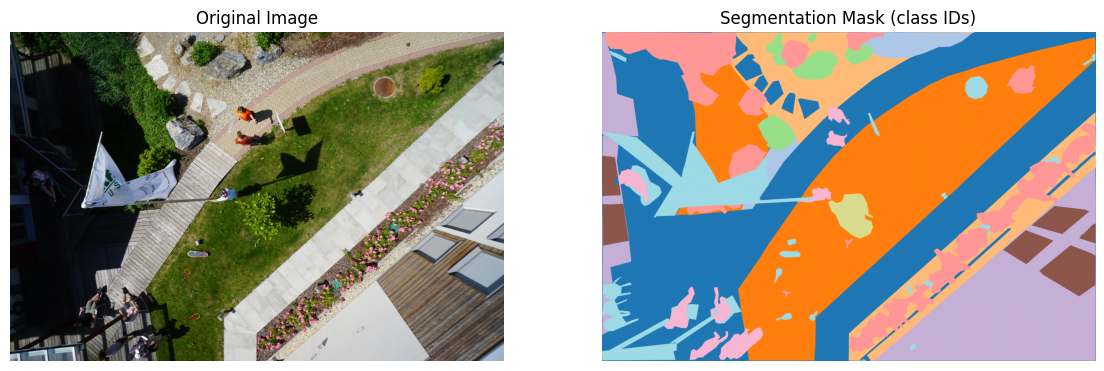

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import os

img_dir = f"{path}/dataset/semantic_drone_dataset/original_images"
mask_dir = f"{path}/dataset/semantic_drone_dataset/label_images_semantic"

# grab one filename to test
sample_name = "372"  # just picking one we saw above

img = Image.open(f"{img_dir}/{sample_name}.jpg")
mask = Image.open(f"{mask_dir}/{sample_name}.png")

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes[0].imshow(img)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(mask, cmap="tab20")  # tab20 = 20 distinct colors for 20 classes
axes[1].set_title("Segmentation Mask (class IDs)")
axes[1].axis("off")
plt.show()


In [ ]:
import torch
from torch.utils.data import Dataset
import numpy as np
import glob

class DroneDataset(Dataset):
    def __init__(self, img_dir, mask_dir, transform=None):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.transform = transform
        # list of all image filenames (without extension), sorted for consistency
        self.ids = sorted([os.path.splitext(f)[0] for f in os.listdir(img_dir)])

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        name = self.ids[idx]
        img = Image.open(f"{self.img_dir}/{name}.jpg").convert("RGB")
        mask = Image.open(f"{self.mask_dir}/{name}.png")

        img = np.array(img)
        mask = np.array(mask)

        if self.transform:
            augmented = self.transform(image=img, mask=mask)
            img = augmented["image"]
            mask = augmented["mask"]

        return img, mask.long()

In [ ]:
!pip install albumentations -q
import albumentations as A
from albumentations.pytorch import ToTensorV2

transform = A.Compose([
    A.Resize(256, 256),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

In [ ]:
dataset = DroneDataset(img_dir, mask_dir, transform=transform)
print("Total samples:", len(dataset))

sample_img, sample_mask = dataset[0]
print("Image shape:", sample_img.shape)
print("Mask shape:", sample_mask.shape)
print("Unique classes in this mask:", torch.unique(sample_mask))

Total samples: 400
Image shape: torch.Size([3, 256, 256])
Mask shape: torch.Size([256, 256])
Unique classes in this mask: tensor([ 0,  1,  2,  4,  8, 10, 15, 19, 22])


In [ ]:
print("Total samples:", len(dataset))
print("Image shape:", sample_img.shape)
print("Mask shape:", sample_mask.shape)
print("Unique classes in this mask:", torch.unique(sample_mask))

Total samples: 400
Image shape: torch.Size([3, 256, 256])
Mask shape: torch.Size([256, 256])
Unique classes in this mask: tensor([ 0,  1,  2,  4,  8, 10, 15, 19, 22])


In [ ]:
import pandas as pd
class_dict = pd.read_csv(f"{path}/class_dict_seg.csv")
print(class_dict)
print("Number of classes:", len(class_dict))

           name    r    g    b
0     unlabeled    0    0    0
1    paved-area  128   64  128
2          dirt  130   76    0
3         grass    0  102    0
4        gravel  112  103   87
5         water   28   42  168
6         rocks   48   41   30
7          pool    0   50   89
8    vegetation  107  142   35
9          roof   70   70   70
10         wall  102  102  156
11       window  254  228   12
12         door  254  148   12
13        fence  190  153  153
14   fence-pole  153  153  153
15       person  255   22   96
16          dog  102   51    0
17          car    9  143  150
18      bicycle  119   11   32
19         tree   51   51    0
20    bald-tree  190  250  190
21    ar-marker  112  150  146
22     obstacle    2  135  115
23  conflicting  255    0    0
Number of classes: 24


In [ ]:
from torch.utils.data import random_split

total_size = len(dataset)
val_size = int(0.2 * total_size)   # 20% for validation
train_size = total_size - val_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}")

Train: 320, Val: 80


In [ ]:
from torch.utils.data import DataLoader

BATCH_SIZE = 8

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

In [ ]:
!pip install segmentation-models-pytorch -q
import segmentation_models_pytorch as smp

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=24,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
print(model.__class__.__name__, "loaded on", device)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 7.3 MB/s eta 0:00:00


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 87.3MB            

model.safetensors: downloading bytes:           |  0.00B            

Unet loaded on cuda


In [ ]:
import torch.nn as nn

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [ ]:
EPOCHS = 10

for epoch in range(EPOCHS):
    model.train()  # tell the model we're in training mode
    train_loss = 0

    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()          # clear old gradients
        outputs = model(images)        # forward pass: get predictions
        loss = loss_fn(outputs, masks) # compare predictions to truth
        loss.backward()                # compute gradients (backpropagation)
        optimizer.step()               # update model weights

        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)

    # validation phase - no learning, just checking
    model.eval()
    val_loss = 0
    with torch.no_grad():  # don't waste memory tracking gradients here
        for images, masks in val_loader:
            images = images.to(device)
            masks = masks.to(device)
            outputs = model(images)
            loss = loss_fn(outputs, masks)
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)

    print(f"Epoch {epoch+1}/{EPOCHS} - Train Loss: {avg_train_loss:.4f} - Val Loss: {avg_val_loss:.4f}")

Epoch 1/10 - Train Loss: 1.0678 - Val Loss: 1.1078
Epoch 2/10 - Train Loss: 1.0198 - Val Loss: 1.0615
Epoch 3/10 - Train Loss: 0.9697 - Val Loss: 1.0152
Epoch 4/10 - Train Loss: 0.9114 - Val Loss: 0.9761
Epoch 5/10 - Train Loss: 0.8703 - Val Loss: 0.9527
Epoch 6/10 - Train Loss: 0.8409 - Val Loss: 0.9273
Epoch 7/10 - Train Loss: 0.7962 - Val Loss: 0.9061
Epoch 8/10 - Train Loss: 0.7705 - Val Loss: 0.9019
Epoch 9/10 - Train Loss: 0.7393 - Val Loss: 0.8725
Epoch 10/10 - Train Loss: 0.7048 - Val Loss: 0.8494


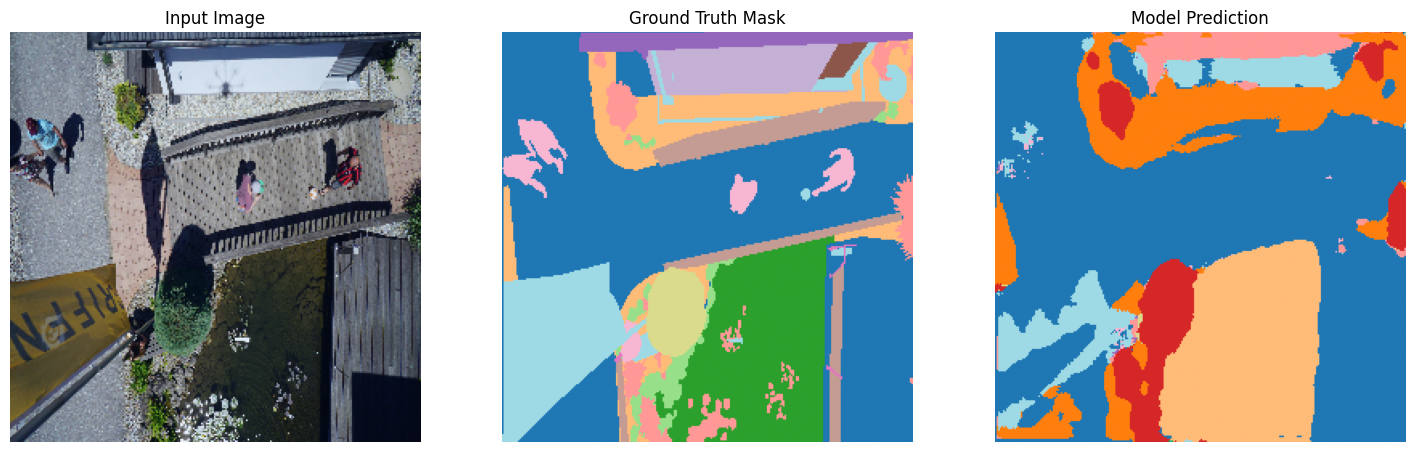

In [ ]:
model.eval()
images, masks = next(iter(val_loader))
images, masks = images.to(device), masks.to(device)

with torch.no_grad():
    outputs = model(images)
    preds = torch.argmax(outputs, dim=1)  # pick the highest-probability class per pixel

idx = 0  # look at the first image in this batch
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

img_show = images[idx].cpu().permute(1, 2, 0).numpy()
img_show = (img_show - img_show.min()) / (img_show.max() - img_show.min())  # undo normalization for display

axes[0].imshow(img_show)
axes[0].set_title("Input Image")
axes[0].axis("off")

axes[1].imshow(masks[idx].cpu(), cmap="tab20")
axes[1].set_title("Ground Truth Mask")
axes[1].axis("off")

axes[2].imshow(preds[idx].cpu(), cmap="tab20")
axes[2].set_title("Model Prediction")
axes[2].axis("off")

plt.show()

In [ ]:
!pip install torchmetrics -q
from torchmetrics.classification import MulticlassJaccardIndex

iou_metric = MulticlassJaccardIndex(num_classes=24, average="macro").to(device)

model.eval()
with torch.no_grad():
    for images, masks in val_loader:
        images, masks = images.to(device), masks.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)
        iou_metric.update(preds, masks)

print("Mean IoU across all classes:", iou_metric.compute().item())


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 36.4 MB/s eta 0:00:00
Mean IoU across all classes: 0.21484342217445374


In [ ]:
iou_per_class = MulticlassJaccardIndex(num_classes=24, average=None).to(device)

model.eval()
with torch.no_grad():
    for images, masks in val_loader:
        images, masks = images.to(device), masks.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)
        iou_per_class.update(preds, masks)

scores = iou_per_class.compute().cpu().numpy()
class_names = class_dict['name'].tolist()

for name, score in zip(class_names, scores):
    print(f"{name:15s}: {score:.3f}")

unlabeled      : 0.000
paved-area     : 0.788
dirt           : 0.144
grass          : 0.867
gravel         : 0.541
water          : 0.739
rocks          : 0.000
pool           : 0.000
vegetation     : 0.544
roof           : 0.703
wall           : 0.004
window         : 0.000
door           : 0.000
fence          : 0.000
fence-pole     : 0.000
person         : 0.019
dog            : 0.000
car            : 0.000
bicycle        : 0.000
tree           : 0.376
bald-tree      : 0.002
ar-marker      : 0.000
obstacle       : 0.214
conflicting    : 0.000
